Link for the dataset csv: https://drive.google.com/file/d/1MdHE8ROS6TmiLjyDuGMv_y-IjJbdm0-l/view?usp=sharing 

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import json
import re
import os
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [2]:
df = pd.read_csv('dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19661 entries, 0 to 19660
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             19661 non-null  object
 1   pub_title      19661 non-null  object
 2   dataset_label  19661 non-null  object
 3   full_text      19661 non-null  object
dtypes: object(4)
memory usage: 614.5+ KB


In [3]:
article_num = df.loc[100, 'full_text']
print(article_num)

 a 5 increase in the us teenage birthrate between 2005 and 2007 brought renewed focus to the issue of teenage childbearing 1 and an estimated 18 of all teenage girls will give birth before age 20 2 the large and growing body of literature on teenage childbearing generally focuses on one of two areas preventing teenage pregnancy or documenting its consequences for young people and their families this study falls into the second category but it does not take the usual route of comparing teenage parents with their childless peers instead it examines differences among young parents using data from the national education longitudinal study nels to explore which teenage parents fi nish high school and which do not this question is an important and conceptually distinct one whose answers should lead to preliminary recommendations for policies targeting teenage parents background high school completion is a particularly important policy concern finishing high school is a minimum credential for

In [4]:
df.head()

,id,pub_title,dataset_label,full_text
0,d0fa7568-7d8e-4db9-870f-f9c6f668c17b,The Impact of Dual Enrollment on College Degre...,national education longitudinal study,what is this study about this study used data ...
1,2f26f645-3dec-485d-b68d-f013c9e05e60,Educational Attainment of High School Dropouts...,national education longitudinal study,november 2004 dropping out of high school is n...
2,c5d5cd2c-59de-4f29-bbb1-6a88c7b52f29,Differences in Outcomes for Female and Male St...,national education longitudinal study,differences in outcomes for female and male st...
3,5c9a3bc9-41ba-4574-ad71-e25c1442c8af,Stepping Stone and Option Value in a Model of ...,national education longitudinal study,abstract federal reserve bank of richmond s1 a...
4,c754dec7-c5a3-4337-9892-c02158475064,"Parental Effort, School Resources, and Student...",national education longitudinal study,abstract this article investigates an importan...


In [4]:
df.shape

(19661, 4)

In [5]:
df['dataset_label'].nunique()

130

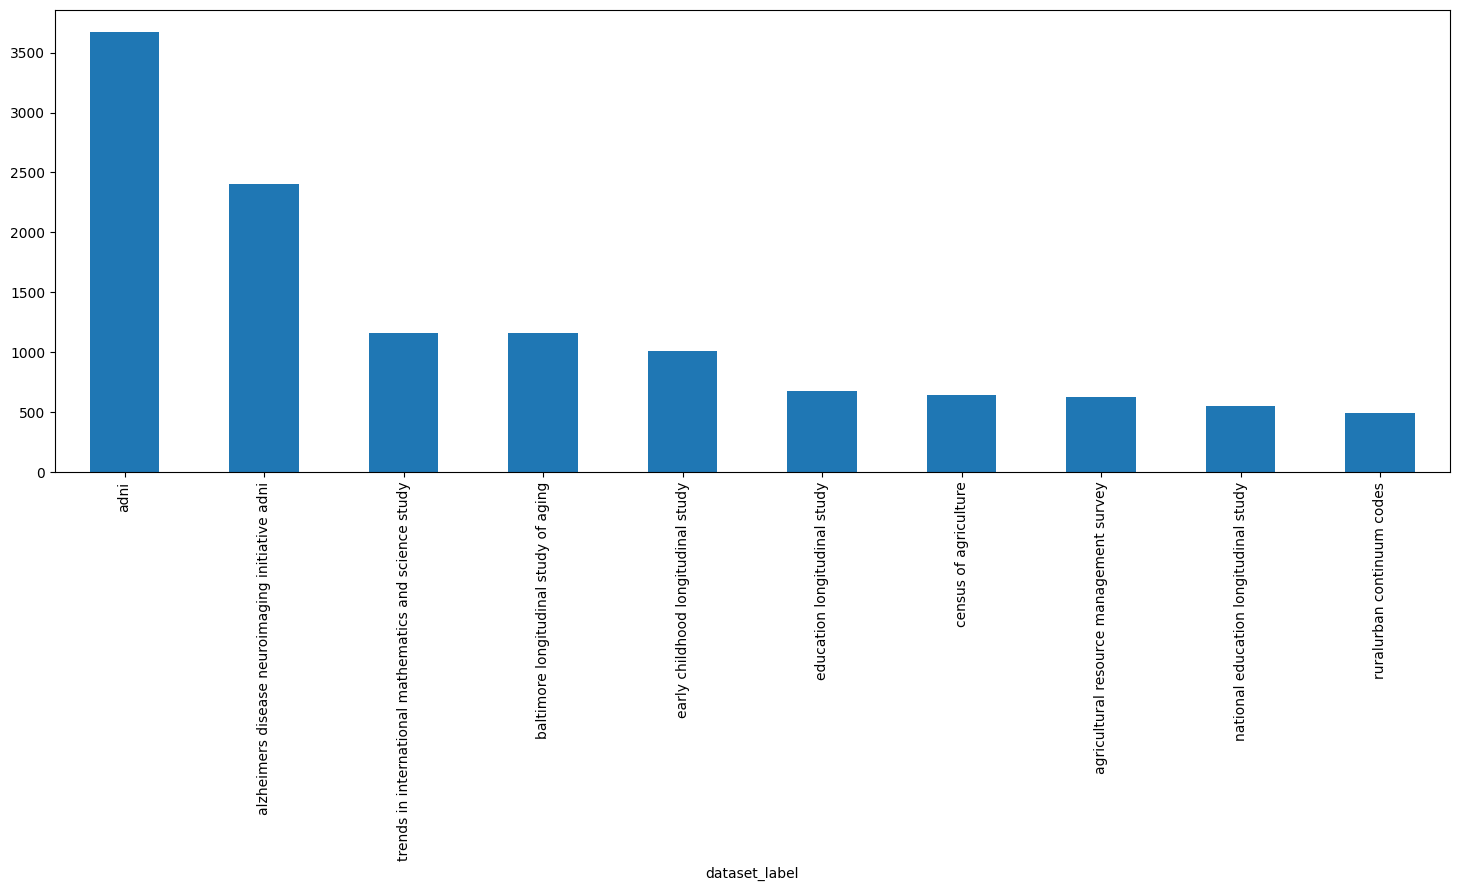

In [6]:
# Plot most referenced datasets
plt.figure(figsize=(18,6))
df['dataset_label'].value_counts().head(10).plot(kind='bar')
plt.show()

There is class imbalance across dataset labels as some datasets are mentioned way more than the others.

In [7]:
df['dataset_label'].value_counts().head(10)

dataset_label
adni                                                     3673
alzheimers disease neuroimaging initiative adni          2400
trends in international mathematics and science study    1163
baltimore longitudinal study of aging                    1156
early childhood longitudinal study                       1011
education longitudinal study                              676
census of agriculture                                     643
agricultural resource management survey                   623
national education longitudinal study                     550
ruralurban continuum codes                                490
Name: count, dtype: int64

The dataset contains total of 19661 articles, with 130 unique datasets references.
The top 10 most frequent datasets are:
```
NAME:                                                    NUMBER OF MENTIONS:
adni                                                     3673
alzheimers disease neuroimaging initiative adni          2400
trends in international mathematics and science study    1163
baltimore longitudinal study of aging                    1156
early childhood longitudinal study                       1011
education longitudinal study                              676
census of agriculture                                     643
agricultural resource management survey                   623
national education longitudinal study                     550
ruralurban continuum codes                                490
```

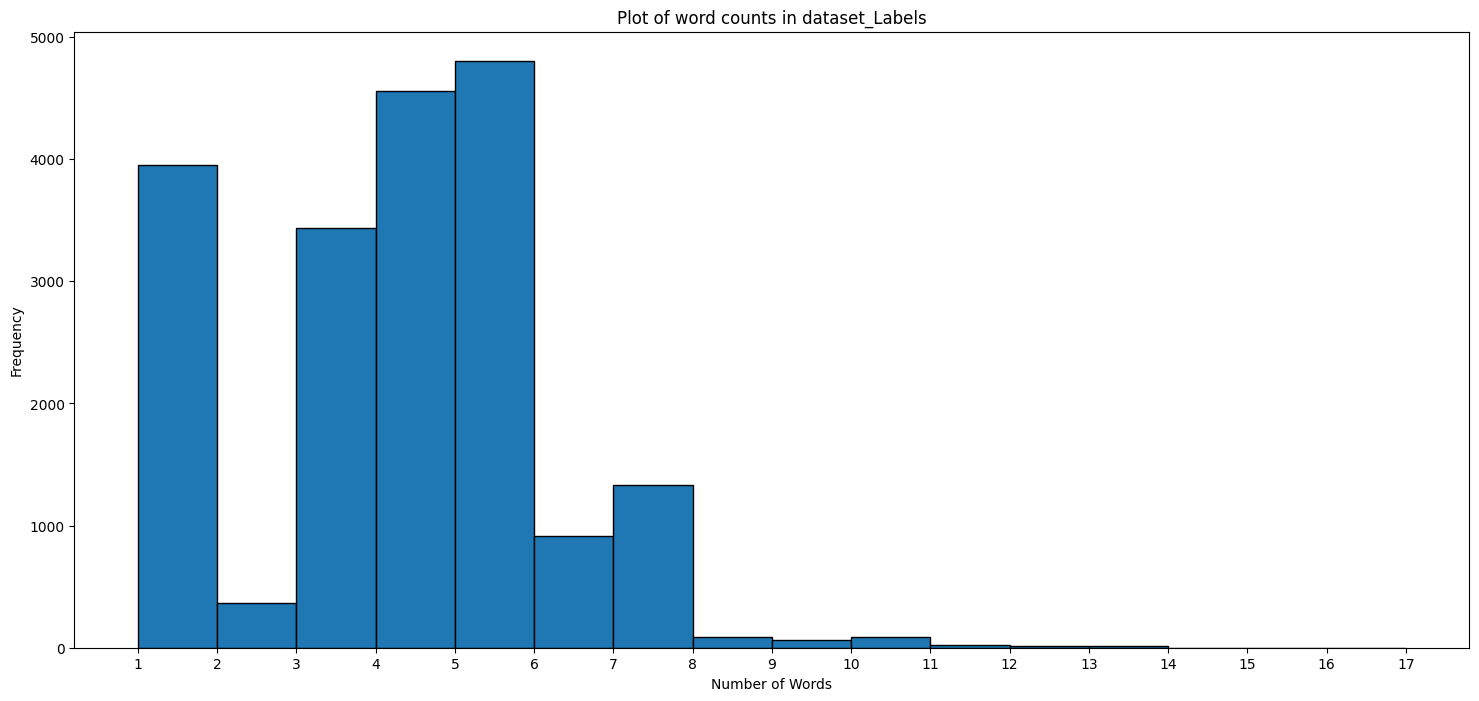

In [ ]:
# Calculate word count for each dataset label
df['dataset_word_count'] = df['dataset_label'].apply(lambda x: len(str(x).split()))

# Plotting the histogram
plt.figure(figsize=(18,8))
plt.hist(df['dataset_word_count'], bins=range(1, df['dataset_word_count'].max()+1), edgecolor='black')
plt.title('Plot of word counts in dataset_labels')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xticks(range(1, df['dataset_word_count'].max()+1))
plt.show()